In [1]:
import pandas as pd
import numpy as np
import re

pd.options.display.max_columns = None

### `Question-1:`

The dataset is based on NFTs. This is quite large. So, when you will read the dataset, you have to wait. The link of the dataset: https://tinyurl.com/2pfhncqw

Your task is to make a pivote table by using the columns "verification_status", "contract_type", "rarity_score" and "last_sale_price" to find out the total values.

**File Deleted, Can't perform Task :((**

### `Question-2:`

You are given a dataset about the cars' price and miles driven of different cars throughout the different years. The link of the dataset: https://tinyurl.com/2r24n45l. Your tasks are
- make a pivot table of the brands (the required brands are given below) from the "Year" 2018 to the year 2022 in which the "Price" is shown as average values and "Miles" are in median values. In this pivote table, every row represents a particular brand and each column represents either average "Price" of a partucular year or median values of "Miles" of a particular year.
- At the end plot a kde chart for the "Price" and "Miles" by using your pivot table.

There are some challenges to solve this task:
- There is no column that is represented to the brand name of the car. You have to find out on your own.
- Some values of "Years" column are misleading. You have to reset this column too that every value should tell a valid meaning.

In [2]:
# code here
df = pd.read_csv('/home/viper/01_DSMP/Tasks/datasets/carvana - carvana.csv')
df

,Name,Year,Miles,Price
0,Chevrolet Trax,2018,41946,16990
1,GMC Terrain,2020,45328,23990
2,Jeep Wrangler,2012,81068,21590
3,Jeep Renegade,2019,35372,21590
4,BMW X,20173,68992,22990
...,...,...,...,...
21995,Honda Accord,2014,98085,17590
21996,Dodge Charger,2016,62616,23990
21997,Ford Taurus,2013,50345,16990
21998,Toyota Corolla Hatchback,2020,27945,23990


In [3]:
df["Brand"] = df["Name"].str.split().str[0]

In [4]:
df

,Name,Year,Miles,Price,Brand
0,Chevrolet Trax,2018,41946,16990,Chevrolet
1,GMC Terrain,2020,45328,23990,GMC
2,Jeep Wrangler,2012,81068,21590,Jeep
3,Jeep Renegade,2019,35372,21590,Jeep
4,BMW X,20173,68992,22990,BMW
...,...,...,...,...,...
21995,Honda Accord,2014,98085,17590,Honda
21996,Dodge Charger,2016,62616,23990,Dodge
21997,Ford Taurus,2013,50345,16990,Ford
21998,Toyota Corolla Hatchback,2020,27945,23990,Toyota


In [5]:
df["Year"] = (df["Year"].astype(str).str[:4].astype(int))
print(df["Brand"].unique())

['Chevrolet' 'GMC' 'Jeep' 'BMW' 'Buick' 'Chrysler' 'Subaru' 'Mitsubishi'
 'Toyota' 'Nissan' 'Lincoln' 'Lexus' 'Dodge' 'Ford' 'MAZDA' 'Volkswagen'
 'Honda' 'FIAT' 'Hyundai' 'Kia' 'Acura' 'INFINITI' 'Scion' 'Audi' 'Alfa'
 'MINI' 'Cadillac' 'Ram' 'Mercedes-Benz' 'Volvo' 'smart' 'Land' 'Tesla'
 'Jaguar' 'Polestar' 'Porsche' 'Genesis' 'Maserati' 'Pontiac' 'Saturn']


In [6]:
required_brands = ['Chevrolet', 'GMC', 'Jeep', 'BMW', 'Buick', 'Chrysler', 'Subaru', 'Mitsubishi', 'Toyota' 'Nissan' 'Lincoln' 'Lexus' 'Dodge' 'Ford' 'MAZDA' 'Volkswagen', 'Honda', 'FIAT', 'Hyundai', 'Kia', 'Acura', 'INFINITI', 'Scion', 'Audi', 'Alfa', 'MINI', 'Cadillac', 'Ram', 'Mercedes-Benz', 'Volvo', 'smart', 'Land', 'Tesla', 'Jaguar', 'Polestar', 'Porsche', 'Genesis', 'Maserati', 'Pontiac', 'Saturn']
required_brands

['Chevrolet',
 'GMC',
 'Jeep',
 'BMW',
 'Buick',
 'Chrysler',
 'Subaru',
 'Mitsubishi',
 'ToyotaNissanLincolnLexusDodgeFordMAZDAVolkswagen',
 'Honda',
 'FIAT',
 'Hyundai',
 'Kia',
 'Acura',
 'INFINITI',
 'Scion',
 'Audi',
 'Alfa',
 'MINI',
 'Cadillac',
 'Ram',
 'Mercedes-Benz',
 'Volvo',
 'smart',
 'Land',
 'Tesla',
 'Jaguar',
 'Polestar',
 'Porsche',
 'Genesis',
 'Maserati',
 'Pontiac',
 'Saturn']

In [7]:
pivot_df = df.pivot_table(index="Name", columns="Year", values=["Price", "Miles"], aggfunc={"Price": "mean", "Miles":"median"})
pivot_df

Miles                                      \
Year                                2009     2010     2011     2012     2013   
Name                                                                           
Acura ILX                            NaN      NaN      NaN      NaN  88914.0   
Acura MDX                            NaN  98825.0      NaN  62768.0      NaN   
Acura MDX Sport Hybrid               NaN      NaN      NaN      NaN      NaN   
Acura RDX                            NaN      NaN  97867.0  48897.0  80576.0   
Acura RLX                            NaN      NaN      NaN      NaN      NaN   
...                                  ...      ...      ...      ...      ...   
Volvo V                              NaN      NaN      NaN      NaN      NaN   
Volvo XC                             NaN      NaN      NaN  70983.0  41216.0   
smart fortwo                         NaN      NaN      NaN  27966.0  28703.0   
smart fortwo electric drive          NaN      NaN      NaN      NaN      NaN   
smart fortwo electric drive cabrio   NaN      NaN      NaN      NaN      NaN   

                                                                        \
Year                                   2014     2015     2016     2017   
Name                                                                     
Acura ILX                           76067.0      NaN  50733.0  53340.5   
Acura MDX                           92011.0  83298.0  82829.5  43791.0   
Acura MDX Sport Hybrid                  NaN      NaN      NaN      NaN   
Acura RDX                           87856.0  62433.0  57525.0  61143.0   
Acura RLX                           69882.0      NaN      NaN      NaN   
...                                     ...      ...      ...      ...   
Volvo V                                 NaN  67942.0  77319.0      NaN   
Volvo XC                            90078.0  73503.5  76102.0  68674.0   
smart fortwo                        47157.0  48621.0  23996.0      NaN   
smart fortwo electric drive         15626.0  33727.0      NaN      NaN   
smart fortwo electric drive cabrio      NaN      NaN      NaN      NaN   

                                                                             \
Year                                   2018     2019     2020     2021 2022   
Name                                                                          
Acura ILX                           32516.0      NaN      NaN      NaN  NaN   
Acura MDX                           86981.0  50959.0      NaN      NaN  NaN   
Acura MDX Sport Hybrid                  NaN  32675.0      NaN      NaN  NaN   
Acura RDX                               NaN  26612.0  30894.0  10922.0  NaN   
Acura RLX                               NaN      NaN      NaN      NaN  NaN   
...                                     ...      ...      ...      ...  ...   
Volvo V                                 NaN      NaN      NaN      NaN  NaN   
Volvo XC                            41490.0  23902.0      NaN  36590.0  NaN   
smart fortwo                            NaN      NaN      NaN      NaN  NaN   
smart fortwo electric drive         20157.5      NaN      NaN      NaN  NaN   
smart fortwo electric drive cabrio  14825.0      NaN      NaN      NaN  NaN   

                                        Price                                 \
Year                               2023  2009     2010     2011         2012   
Name                                                                           
Acura ILX                           NaN   NaN      NaN      NaN          NaN   
Acura MDX                           NaN   NaN  16590.0      NaN  20790.00000   
Acura MDX Sport Hybrid              NaN   NaN      NaN      NaN          NaN   
Acura RDX                           NaN   NaN      NaN  14990.0  19971.56682   
Acura RLX                           NaN   NaN      NaN      NaN          NaN   
...                                 ...   ...      ...      ...          ...   
Volvo V                             NaN   NaN     

### `Question-3:`

You are given a dataset of **Daily Power Generation in India** of regional wise of all Power Stations. Link of the dataset: https://tinyurl.com/2nq6kugt

Task
- In this dataset, there are many columns. Two of them are `Actual(MU)` and `Excess(+) / Shortfall (-)`. `Actual(MU)` represents the actual power generation. `Excess(+) / Shortfall (-)` tells is that generated power is excess or shortfall for that particular day of a power station. You have to find out what should be the actual power generation required for that day by the power stations that there would not be any excess or shorfall power. For the result, make a new column.
- Find out the month of the day and store it as a new column.
- Find out top 10 frequently appeared power stations in this dataframe.
- Next create a pivot table of which every row represents a power station and every column represents a month in a order. Like January, February, March...
- It is hard to get inside if you look through the only pivot table. So plot the pivot table.

In [8]:
url = "https://tinyurl.com/2nq6kugt"
df = pd.read_csv(url)
df

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation
0,2017-09-01,Delhi,2235.4,135.00,0.00,135.0,0,13,18,5.00,0.0
1,2017-09-01,Haryana,2720.0,2470.00,0.00,2470.0,0,28,7,-21.80,0.0
2,2017-09-01,Himachal Pradesh,3378.0,379.00,0.00,231.0,0,40,46,5.63,0.0
3,2017-09-01,Jammu and Kashmir,1285.0,150.00,0.00,0.0,0,14,23,9.43,0.0
4,2017-09-01,Punjab,3826.3,2697.65,77.65,2620.0,0,39,17,-21.69,0.0
...,...,...,...,...,...,...,...,...,...,...,...
345268,2022-04-13,Tripura,137.0,32.00,0.00,0.0,32,0,1,0.29,0.0
345269,2022-04-13,NEEPCO.,2027.0,963.50,313.50,650.0,0,0,12,-1.59,0.0
345270,2022-04-13,NHPC,105.0,35.00,0.00,35.0,0,0,0,-0.72,0.0
345271,2022-04-13,NTPC Ltd.,750.0,250.00,0.00,250.0,0,0,11,4.45,0.0


<Axes: xlabel='Power Station'>

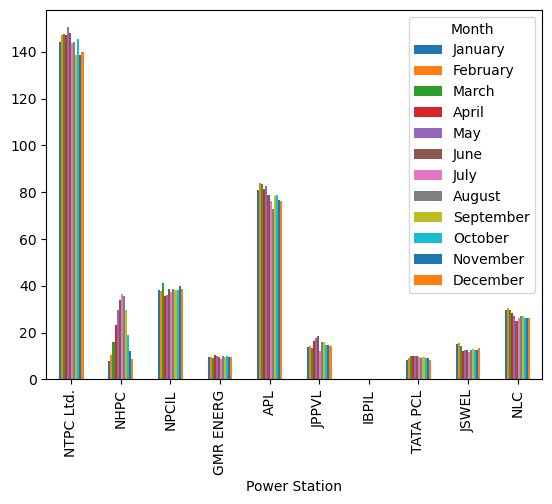

In [9]:
df["Required_Generation"] = df["Actual(MU)"] - df["Excess(+) / Shortfall (-)"]

df["Dates"] = pd.to_datetime(df["Dates"])
df["Month"] = df["Dates"].dt.month_name()

top10 = df["Power Station"].value_counts().head(10)

pivot_df = df.pivot_table(
    index="Power Station",
    columns="Month",
    values="Required_Generation",
    aggfunc="mean"
)

month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

pivot_df = pivot_df[month_order]

pivot_df.loc[top10.index].plot(kind="bar")

### `Q-4` You are given a file `question-answer.csv`. Your task is to make a dataframe from it with two columns - `question` and `answers`.

* Questions in the file start from `Q<number>`; E.g.  `Q1` denotes question no. `1`
* Answers starts from `Ans<number>`; Eg. `Ans1` denotes answer of question no `1`
* MAke sure you look at columns name carefully

CSV File - "https://drive.google.com/file/d/10rmV3XrVtzpDTtYZF3UtCdcU0ajBJjGY/view?usp=share_link"

In [10]:
# code here

df = pd.read_csv("datasets/question-answer.csv")
df.sample(5)

,Unnamed: 0,2
8,8,Q5-You are given a data set consisting of vari...
10,10,Q6-What is bag of words? How we can use it for...
6,6,Q4-How can you avoid overfitting your model?
0,0,Q1-What is Data Science?
9,9,Ans5-The following are ways to handle missing ...


In [11]:
col = df.columns[1]

questions = df[df[col].astype(str).str.startswith("Q")][col].str.split("-", n=1).str[1].reset_index(drop=True)

answers = df[df[col].astype(str).str.startswith("Ans")][col].str.split("-", n=1).str[1].reset_index(drop=True)

final_df = pd.DataFrame({
    "question": questions,
    "answer": answers
})

final_df

,question,answer
0,What is Data Science?,"Data Science combines statistics, maths, speci..."
1,2. How is logistic regression done?,Logistic regression measures the relationship ...
2,How do you build a random forest model?,A random forest is built up of a number of dec...
3,How can you avoid overfitting your model?,Overfitting refers to a model that is only set...
4,You are given a data set consisting of variabl...,The following are ways to handle missing data ...
5,What is bag of words? How we can use it for te...,Bag of Words is a representation of text that ...
6,How can we use machine learning for text class...,Machine learning classification algorithms pre...
7,What is a time series?,A time series is a set of observations ordered...
8,How is time series different from the usual re...,The principle behind causal forecasting is tha...
9,What are the different types of joins? What ar...,(INNER) JOIN: Returns records that have matchi...


### `Q-5`: Print Question and answer of those questions which does not contains any question mark (`?`).


In [12]:
# code here

result = final_df[
    ~final_df["question"]
    .astype(str)
    .str.contains(r"\?", regex=True, na=False)
]

print(result)

Empty DataFrame
Columns: [question, answer]
Index: []


### `Q 6-10` LOG and EMPLOYEE
6. Show `activity` details month wise. Show count for each `activity`
7. Find employee who did most `activity` in January month.
8. Employee who have worked most no of times on Weekends.
9. Which activity is logged most on buisness days.
10. Week Days wise activity table.
```
log_file = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT-OMrmmNdOTM-B5f5F1EpCutMVG230UZiLvqlsg0NIKUKR3yrqiI2r1pEX-LvSEk-3WwySPYtvbBC-/pub?gid=1937029224&single=true&output=csv")
employee = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQ5AuFqRjSZVBKm5zyDxquX6utubq1DJKkYDI70vjeidAnyAu70KMSYpMYzeVSNVTeUIJBpfF6jU5E6/pub?gid=798824749&single=true&output=csv")

```

Note(for common field):- Employee file has `EMPLOYEE_ID` and LOG file has `emp_id`

In [13]:
# code here

log_file = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT-OMrmmNdOTM-B5f5F1EpCutMVG230UZiLvqlsg0NIKUKR3yrqiI2r1pEX-LvSEk-3WwySPYtvbBC-/pub?gid=1937029224&single=true&output=csv")
employee = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQ5AuFqRjSZVBKm5zyDxquX6utubq1DJKkYDI70vjeidAnyAu70KMSYpMYzeVSNVTeUIJBpfF6jU5E6/pub?gid=798824749&single=true&output=csv")

df = log_file.merge(employee, left_on="emp_id", right_on="EMPLOYEE_ID")
df

,Log_ID,dt,dept,emp_id,activity,eqpt,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,EMAIL
0,1000,2022-01-07,Dept6,115,Cleaning,UPS,115,Alexander,Khoo,AKHOO
1,1001,2022-01-08,Dept4,105,Cleaning,Generator,105,David,Austin,DAUSTIN
2,1002,2022-01-09,Dept3,112,Inspection,CPU,112,NaN,Urman,JMURMAN
3,1003,2022-01-10,Dept4,120,Inspection,UPS,120,Matthew,Weiss,MWEISS
4,1004,2022-01-11,Dept3,138,Checking,Battery,138,Stephen,Stiles,SSTILES
...,...,...,...,...,...,...,...,...,...,...
290,1360,2023-01-02,Dept2,122,Repair,AC,122,Payam,Kaufling,PKAUFLING
291,1361,2023-01-03,Dept4,116,Checking,Server,116,Shelli,Baida,SBAIDA
292,1362,2023-01-04,Dept4,110,Checking,CPU,110,John,Chen,JCHEN
293,1363,2023-01-05,Dept4,102,Inspection,AC,102,Lex,De Haan,LDEHAAN


In [14]:
df["dt"] = pd.to_datetime(df["dt"])
df["Month"] = df["dt"].dt.month_name()
df["Weekday"] = df["dt"].dt.day_name()
df["is_weekend"] = df["Weekday"].isin(["Saturday", "Sunday"])

print(df.groupby(["Month", "activity"]).size().unstack(fill_value=0))

print(df[df["Month"]=="January"].groupby("emp_id").size().idxmax())

print(df[df["is_weekend"]].groupby("emp_id").size().idxmax())

print(df[~df["is_weekend"]].groupby("activity").size().idxmax())

print(df.groupby(["Weekday","activity"]).size().unstack(fill_value=0))

activity   Checking  Cleaning  Inspection  Repair
Month                                            
April             3         9           7       2
August            7         9           9       4
December          5         4           7       5
February          4         6           4      10
January           6         9           7       5
July              5         5          10       2
June              4         5           8       9
March             6         4           4      12
May               4         7           6       8
November          6         9           4       6
October          11         3           5       5
September         8         2          10       5
122
109
Inspection
activity   Checking  Cleaning  Inspection  Repair
Weekday                                          
Friday            7        15          15       8
Monday            9         9          11      12
Saturday          9         8           6      11
Sunday           11         9  

### `Q-11`:

1. There are missing value in first name of employee. Fill it using email and last name field.

> E.g- `email` -> JMURMAN and `last_name` -> 'Urman' -> so make it's first name as 'JM', Sort of (Email- lastname).

> Email is constructed from initials of first name concate with lastname. Your Task is to fill first name initials in missing data.

2. You can see email field don't have any domain name. Change this to full email addreess with domain as 'campusx.com'.
E.g- Email field -> `JMURMAN`  result -> `JMURMAN@CAMPUSX.COM`

3. Show Full Name of all the employees whose name starts with 'A' and has done any of these activity ['Incpection', 'Cleaning', 'Checking]

In [15]:
# code here

mask = employee["FIRST_NAME"].isna()

employee.loc[mask, "FIRST_NAME"] = (
    employee.loc[mask, "EMAIL"]
    .str.replace(employee.loc[mask, "LAST_NAME"], "", regex=False)
)

employee["EMAIL"] = employee["EMAIL"] + "@CAMPUSX.COM"

df = log_file.merge(employee, left_on="emp_id", right_on="EMPLOYEE_ID")

result = df[
    (df["FIRST_NAME"].str.startswith("A", na=False)) &
    (df["activity"].isin(["Inspection", "Cleaning", "Checking"]))
]

result["FULL_NAME"] = result["FIRST_NAME"] + " " + result["LAST_NAME"]

print(result[["FULL_NAME"]].drop_duplicates())

           FULL_NAME
0     Alexander Khoo
78  Alexander Hunold


/tmp/ipykernel_147155/4203570936.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result["FULL_NAME"] = result["FIRST_NAME"] + " " + result["LAST_NAME"]
